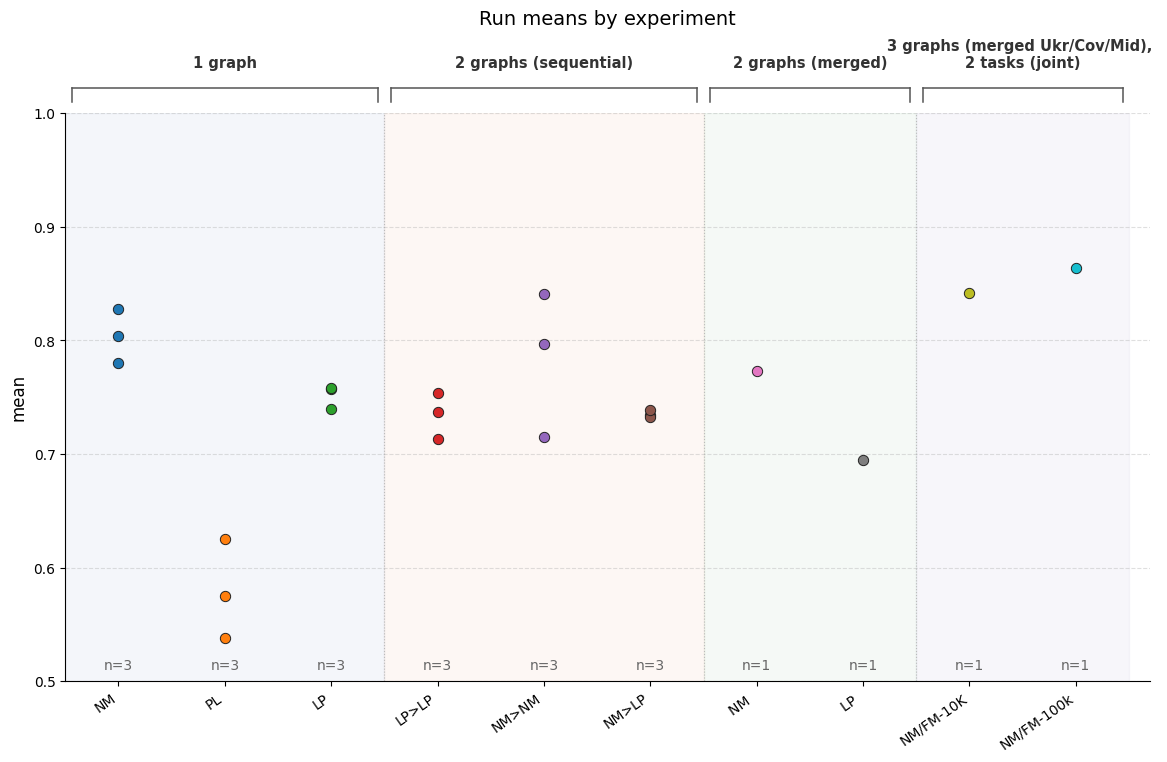

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# (mean, Experiment, train_id)
rows = [
    (0.828, "NM", "covid19_twitter+nm"),
    (0.780, "NM", "midterm+nm"),
    (0.804, "NM", "ukr_rus_twitter+nm"),
    (0.538, "PL", "covid19_twitter+pl"),
    (0.575, "PL", "ukr_rus_twitter+pl"),
    (0.625, "PL", "midterm+pl"),
    (0.757, "LP", "covid19_twitter+lp"),
    (0.740, "LP", "midterm+lp"),
    (0.758, "LP", "ukr_rus_twitter+lp"),
    (0.737, "LP>LP", "covid19_twitter+lp>ukr_rus_twitter+lp"),
    (0.713, "LP>LP", "midterm+lp>covid19_twitter+lp"),
    (0.754, "LP>LP", "midterm+lp>ukr_rus_twitter+lp"),
    (0.715, "NM>NM", "covid19_twitter+nm>ukr_rus_twitter+nm"),
    (0.841, "NM>NM", "midterm+nm>covid19_twitter+nm"),
    (0.797, "NM>NM", "midterm+nm>ukr_rus_twitter+nm"),
    (0.734, "NM>LP", "midterm+nm>covid19_twitter+lp"),
    (0.733, "NM>LP", "covid19_twitter+nm>ukr_rus_twitter+lp"),
    (0.739, "NM>LP", "midterm+nm>ukr_rus_twitter+lp"),
    # (0.773, "NM-Ukr/Cov", "merged_nm"),
    # (0.695, "LP-Ukr/Cov", "merged_lp"),
    (0.773, "NM ", "merged_nm"),
    (0.695, "LP ", "merged_lp"),
    (0.842, "NM/FM-10K", "merged_ukr_covid_midterm_aug_10k"),
    (0.864, "NM/FM-100k", "merged_ukr_covid_midterm_aug_100k"),
]

# group rows by experiment, preserving first-seen order
order, groups = [], {}
for val, exp, tid in rows:
    if exp not in groups:
        groups[exp] = []
        order.append(exp)
    groups[exp].append((val, tid))

positions = np.arange(1, len(order) + 1)
cmap = plt.cm.tab10(np.linspace(0, 1, len(order)))

fig, ax = plt.subplots(figsize=(14, 8))

# Manually allocate space at the top for brackets/title instead of using tight_layout
fig.subplots_adjust(top=0.82)

# boxplots (drawn first, behind the dots), alpha 0.5
data = [[v for v, _ in groups[e]] for e in order]
# bp = ax.boxplot(
#     data, positions=positions, widths=0.55, patch_artist=True, showfliers=False,
#     medianprops=dict(color="#1a1a1a", linewidth=1.4),
#     whiskerprops=dict(color="#666", linewidth=1.0),
#     capprops=dict(color="#666", linewidth=1.0),
#     boxprops=dict(linewidth=1.0, edgecolor="#444"),
#     zorder=1,
# )
# for patch, c in zip(bp["boxes"], cmap):
#     patch.set_facecolor(c)
#     patch.set_alpha(0.5)

# individual run means as aligned dots
for pos, exp, c in zip(positions, order, cmap):
    vals = [v for v, _ in groups[exp]]
    ax.scatter([pos] * len(vals), vals, s=55, color=c,
               edgecolor="#222", linewidth=0.7, zorder=3)

# --- category groupings ---------------------------------------------------
cats = [
    (0, 2, "1 graph"),
    (3, 5, "2 graphs (sequential)"),
    (6, 7, "2 graphs (merged Ukr/Cov)"),
    (8, 9, "3 graphs (merged Ukr/Cov/Mid), \n2 tasks (joint)"),
]
band_tints = ["#4C72B0", "#DD8452", "#55A868", "#8172B3"]
tr = ax.get_xaxis_transform()  # x in data coords, y in axes fraction
for (a, b, name), tint in zip(cats, band_tints):
    xl, xr = positions[a] - 0.5, positions[b] + 0.5
    ax.axvspan(xl, xr, color=tint, alpha=0.06, zorder=0)
    cx = (positions[a] + positions[b]) / 2
    # bracket above the plot
    ax.plot([xl + 0.06, xr - 0.06], [1.045, 1.045], color="#555",
            lw=1.1, transform=tr, clip_on=False)
    ax.plot([xl + 0.06, xl + 0.06], [1.045, 1.02], color="#555",
            lw=1.1, transform=tr, clip_on=False)
    ax.plot([xr - 0.06, xr - 0.06], [1.045, 1.02], color="#555",
            lw=1.1, transform=tr, clip_on=False)
    ax.text(cx, 1.075, name, ha="center", va="bottom", fontsize=10.5,
            fontweight="bold", color="#333", transform=tr, clip_on=False)
# dotted separators between categories
for (_, b, _) in cats[:-1]:
    ax.axvline(positions[b] + 0.5, color="#bbb", lw=0.8, ls=":", zorder=0)

# axes cosmetics
ax.set_xticks(positions)
ax.set_xticklabels(order, rotation=35, ha="right", fontsize=10)
ax.set_xlim(0.5, len(order) + 0.7)
ax.set_ylim(0.5, 1)
ax.set_ylabel("mean", fontsize=12)
ax.set_title("Run means by experiment", fontsize=14, pad=64)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

# n= labels under each group
tr_bottom = ax.get_xaxis_transform()  # x is data coords, y is axes fraction (0=bottom, 1=top)
for pos, exp in zip(positions, order):
    # y=-0.15 places it just below your rotated x-axis labels
    ax.text(pos, 0.04, f"n={len(groups[exp])}", ha="center", va="top",
            fontsize=10, color="#666", transform=tr_bottom, clip_on=False)

# Saved without tight layout layout algorithms, but preserving elements outside bounding box
# fig.savefig("figures/experiment_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()

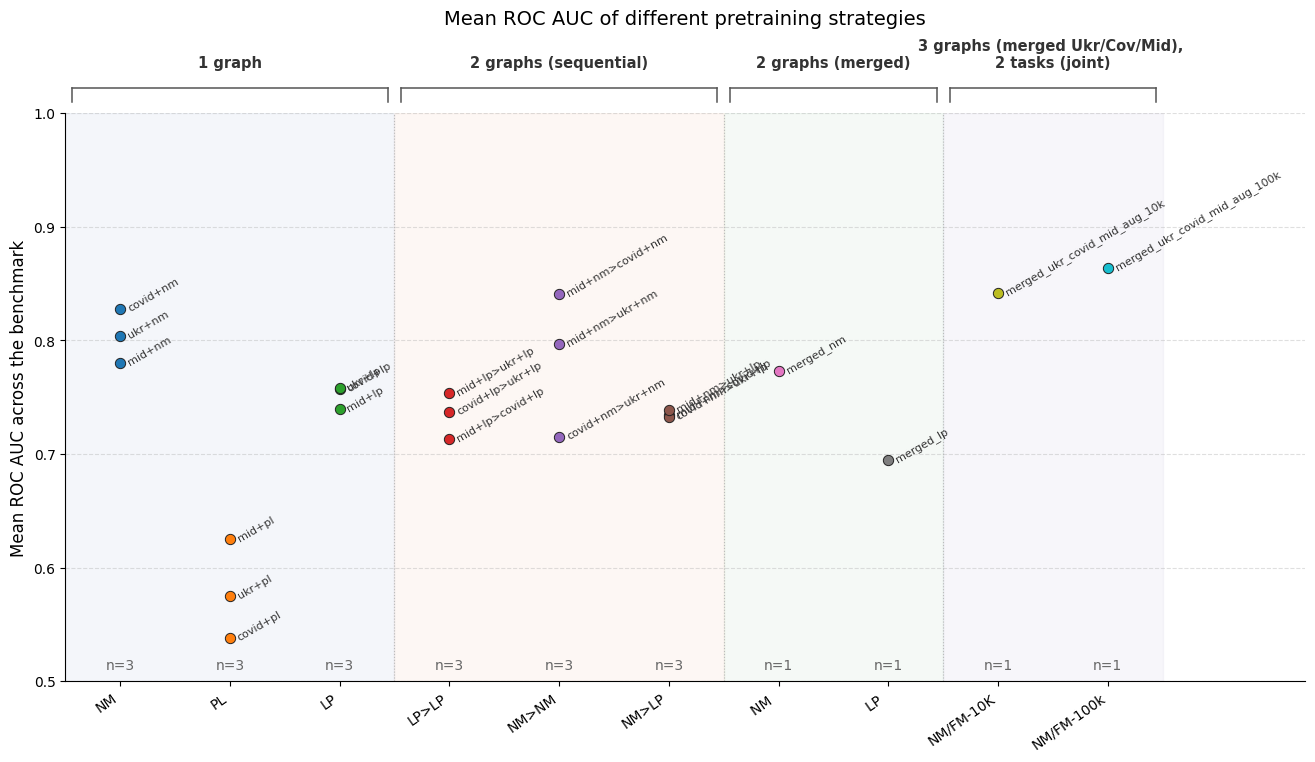

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# (mean, Experiment, train_id)
rows = [
    (0.828, "NM", "covid19_twitter+nm"),
    (0.780, "NM", "midterm+nm"),
    (0.804, "NM", "ukr_rus_twitter+nm"),
    (0.538, "PL", "covid19_twitter+pl"),
    (0.575, "PL", "ukr_rus_twitter+pl"),
    (0.625, "PL", "midterm+pl"),
    (0.757, "LP", "covid19_twitter+lp"),
    (0.740, "LP", "midterm+lp"),
    (0.758, "LP", "ukr_rus_twitter+lp"),
    (0.737, "LP>LP", "covid19_twitter+lp>ukr_rus_twitter+lp"),
    (0.713, "LP>LP", "midterm+lp>covid19_twitter+lp"),
    (0.754, "LP>LP", "midterm+lp>ukr_rus_twitter+lp"),
    (0.715, "NM>NM", "covid19_twitter+nm>ukr_rus_twitter+nm"),
    (0.841, "NM>NM", "midterm+nm>covid19_twitter+nm"),
    (0.797, "NM>NM", "midterm+nm>ukr_rus_twitter+nm"),
    (0.734, "NM>LP", "midterm+nm>covid19_twitter+lp"),
    (0.733, "NM>LP", "covid19_twitter+nm>ukr_rus_twitter+lp"),
    (0.739, "NM>LP", "midterm+nm>ukr_rus_twitter+lp"),
    (0.773, "NM ", "merged_nm"),
    (0.695, "LP ", "merged_lp"),
    (0.842, "NM/FM-10K", "merged_ukr_covid_midterm_aug_10k"),
    (0.864, "NM/FM-100k", "merged_ukr_covid_midterm_aug_100k"),
]

def short_label(tid):
    return (
        tid.replace("covid19_twitter", "covid")
           .replace("ukr_rus_twitter", "ukr")
           .replace("midterm", "mid")
           .replace("merged_ukr_covid_midterm_aug_", "FM-")
    )

# group rows by experiment, preserving first-seen order
order, groups = [], {}
for val, exp, tid in rows:
    if exp not in groups:
        groups[exp] = []
        order.append(exp)
    groups[exp].append((val, tid))

positions = np.arange(1, len(order) + 1)
cmap = plt.cm.tab10(np.linspace(0, 1, len(order)))

fig, ax = plt.subplots(figsize=(16, 8))

# Manually allocate space at the top for brackets/title
fig.subplots_adjust(top=0.82)

# individual run means as aligned dots + labels
for pos, exp, c in zip(positions, order, cmap):
    vals_tids = groups[exp]

    ax.scatter(
        [pos] * len(vals_tids),
        [v for v, _ in vals_tids],
        s=55,
        color=c,
        edgecolor="#222",
        linewidth=0.7,
        zorder=3,
    )

    for v, tid in vals_tids:
        ax.annotate(
            short_label(tid),
            xy=(pos, v),
            xytext=(6, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=8,
            color="#333",
            zorder=4,
            rotation_mode="anchor",
            rotation=30,
        )

# --- category groupings ---------------------------------------------------
cats = [
    (0, 2, "1 graph"),
    (3, 5, "2 graphs (sequential)"),
    (6, 7, "2 graphs (merged)"),
    (8, 9, "3 graphs (merged Ukr/Cov/Mid), \n2 tasks (joint)"),
]

band_tints = ["#4C72B0", "#DD8452", "#55A868", "#8172B3"]
tr = ax.get_xaxis_transform()  # x in data coords, y in axes fraction

for (a, b, name), tint in zip(cats, band_tints):
    xl, xr = positions[a] - 0.5, positions[b] + 0.5

    ax.axvspan(xl, xr, color=tint, alpha=0.06, zorder=0)

    cx = (positions[a] + positions[b]) / 2

    # bracket above the plot
    ax.plot(
        [xl + 0.06, xr - 0.06],
        [1.045, 1.045],
        color="#555",
        lw=1.1,
        transform=tr,
        clip_on=False,
    )
    ax.plot(
        [xl + 0.06, xl + 0.06],
        [1.045, 1.02],
        color="#555",
        lw=1.1,
        transform=tr,
        clip_on=False,
    )
    ax.plot(
        [xr - 0.06, xr - 0.06],
        [1.045, 1.02],
        color="#555",
        lw=1.1,
        transform=tr,
        clip_on=False,
    )
    ax.text(
        cx,
        1.075,
        name,
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color="#333",
        transform=tr,
        clip_on=False,
    )

# dotted separators between categories
for (_, b, _) in cats[:-1]:
    ax.axvline(
        positions[b] + 0.5,
        color="#bbb",
        lw=0.8,
        ls=":",
        zorder=0,
    )

# axes cosmetics
ax.set_xticks(positions)
ax.set_xticklabels(order, rotation=35, ha="right", fontsize=10)

# extra space on the right so point labels are not clipped
ax.set_xlim(0.5, len(order) + 1.8)

ax.set_ylim(0.5, 1)
ax.set_ylabel("Mean ROC AUC across the benchmark", fontsize=12)
ax.set_title("Mean ROC AUC of different pretraining strategies", fontsize=14, pad=64)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

# n= labels under each group
tr_bottom = ax.get_xaxis_transform()
for pos, exp in zip(positions, order):
    ax.text(
        pos,
        0.04,
        f"n={len(groups[exp])}",
        ha="center",
        va="top",
        fontsize=10,
        color="#666",
        transform=tr_bottom,
        clip_on=False,
    )

# Optional save:
# fig.savefig("experiment_boxplots_labeled.png", dpi=200, bbox_inches="tight")

plt.show()

saved


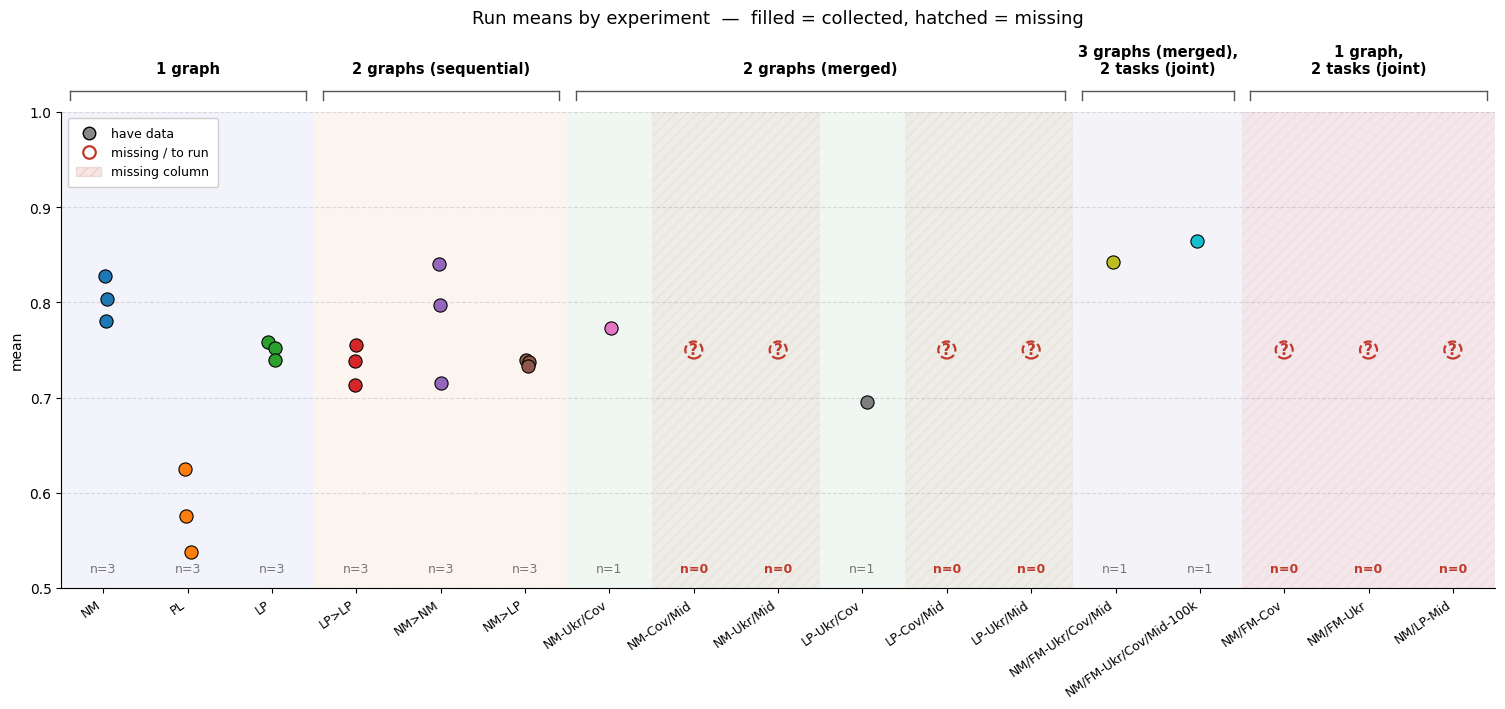

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np

# ----------------------------------------------------------------------
# Data. `vals=None` marks a MISSING / not-yet-run experiment (placeholder).
# Existing values are read approximately off the original figure -- swap in
# exact numbers as you collect them.
# ----------------------------------------------------------------------
COLS = [
    # label,                       color,      vals
    ("NM",                         "#1f77b4", [0.828, 0.804, 0.780]),
    ("PL",                         "#ff7f0e", [0.625, 0.575, 0.538]),
    ("LP",                         "#2ca02c", [0.758, 0.752, 0.740]),

    ("LP>LP",                      "#d62728", [0.755, 0.738, 0.713]),
    ("NM>NM",                      "#9467bd", [0.840, 0.797, 0.715]),
    ("NM>LP",                      "#8c564b", [0.740, 0.737, 0.733]),

    ("NM-Ukr/Cov",                 "#e377c2", [0.773]),
    ("NM-Cov/Mid",                 None,      None),
    ("NM-Ukr/Mid",                 None,      None),
    ("LP-Ukr/Cov",                 "#7f7f7f", [0.695]),
    ("LP-Cov/Mid",                 None,      None),
    ("LP-Ukr/Mid",                 None,      None),

    ("NM/FM-Ukr/Cov/Mid",          "#bcbd22", [0.842]),
    ("NM/FM-Ukr/Cov/Mid-100k",     "#17becf", [0.865]),

    ("NM/FM-Cov",                  None,      None),
    ("NM/FM-Ukr",                  None,      None),
    ("NM/LP-Mid",                  None,      None),
]

# section label, start index, end index (inclusive), background tint
SECTIONS = [
    ("1 graph",                        0,  2, "#f3f4fb"),
    ("2 graphs (sequential)",          3,  5, "#fcf4ee"),
    ("2 graphs (merged)",              6, 11, "#f0f6f1"),
    ("3 graphs (merged),\n2 tasks (joint)", 12, 13, "#f3f3f8"),
    ("1 graph,\n2 tasks (joint)",      14, 16, "#f6f1f6"),
]

MISS_EDGE = "#c0392b"   # red for missing markers/labels
Y_MIN, Y_MAX = 0.5, 1.0
rng = np.random.default_rng(7)

fig, ax = plt.subplots(figsize=(15.5, 8.2))

# --- section background tints (full height) ---
for _, i0, i1, tint in SECTIONS:
    ax.axvspan(i0 - 0.5, i1 + 0.5, color=tint, zorder=0)

# --- per-column drawing ---
for x, (label, color, vals) in enumerate(COLS):
    if vals is None:
        # MISSING: hatched highlight + hollow dashed marker + ? + n=0
        ax.axvspan(x - 0.5, x + 0.5, facecolor=MISS_EDGE, alpha=0.05,
                   hatch="///", edgecolor=MISS_EDGE, linewidth=0, zorder=1)
        ax.scatter([x], [0.75], s=150, facecolors="none", edgecolors=MISS_EDGE,
                   linewidths=1.6, linestyle="--", zorder=3)
        ax.text(x, 0.75, "?", ha="center", va="center", color=MISS_EDGE,
                fontsize=11, fontweight="bold", zorder=4)
        ax.text(x, Y_MIN + 0.013, "n=0", ha="center", va="bottom",
                color=MISS_EDGE, fontsize=9, fontweight="bold")
    else:
        jitter = rng.uniform(-0.05, 0.05, size=len(vals))
        ax.scatter(x + jitter, vals, s=90, color=color, edgecolors="black",
                   linewidths=0.8, zorder=3)
        ax.text(x, Y_MIN + 0.013, f"n={len(vals)}", ha="center", va="bottom",
                color="#777777", fontsize=9)

# --- axes cosmetics ---
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlim(-0.5, len(COLS) - 0.5)
ax.set_ylabel("mean")
ax.set_yticks(np.arange(0.5, 1.01, 0.1))
ax.set_xticks(range(len(COLS)))
ax.set_xticklabels([c[0] for c in COLS], rotation=35, ha="right", fontsize=9)
ax.yaxis.grid(True, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

# --- section brackets above the plot (x in data coords, y in axes fraction) ---
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for name, i0, i1, _ in SECTIONS:
    y_bar, y_tick, y_text = 1.045, 1.025, 1.075
    ax.plot([i0 - 0.4, i1 + 0.4], [y_bar, y_bar], color="#555555",
            lw=1.0, transform=trans, clip_on=False)
    for xe in (i0 - 0.4, i1 + 0.4):
        ax.plot([xe, xe], [y_bar, y_tick], color="#555555", lw=1.0,
                transform=trans, clip_on=False)
    ax.text((i0 + i1) / 2, y_text, name, ha="center", va="bottom",
            fontsize=10.5, fontweight="bold", transform=trans, clip_on=False)

# --- legend ---
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#888888",
           markeredgecolor="black", markersize=9, label="have data"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="none",
           markeredgecolor=MISS_EDGE, markeredgewidth=1.6, linestyle="--",
           markersize=9, label="missing / to run"),
    Patch(facecolor=MISS_EDGE, alpha=0.12, hatch="///", edgecolor=MISS_EDGE,
          label="missing column"),
]
ax.legend(handles=legend_handles, loc="upper left", framealpha=0.95,
          fontsize=9, borderpad=0.7)

ax.set_title("Run means by experiment  —  filled = collected, hatched = missing",
             pad=64, fontsize=13)
fig.subplots_adjust(top=0.80, bottom=0.22, left=0.06, right=0.985)

# fig.savefig("/home/claude/missing_chart.png", dpi=150)
# print("saved")